In [ ]:
import sys

sys.path.insert(0, r"D:\Kuliah\SEMESTER 6\PEMODELAN & SIMULASI\project")

In [17]:
from simulation.experiment import run_experiment

results_df = run_experiment()
results_df
display(results_df.style
    .format({
        "bp_waiting_time": "{:.3f}",
        "bp_queue_length": "{:.3f}",
        "general_waiting_time": "{:.3f}",
        "general_queue_length": "{:.3f}",
        "patients_completed": "{:.0f}"
    })
    .background_gradient(
        subset = [
            "bp_waiting_time",
            "bp_queue_length",
            "general_waiting_time",
            "general_queue_length",
            "patients_completed"
        ],
        cmap = "Reds"
    )
)

INITIAL 100 2.1969722981636908 75.21028497782589 1.150375939849624 43.697278911564624 272
INITIAL 101 1.1180336160103723 61.48626888505947 0.47863247863247865 35.44404332129964 281
INITIAL 102 2.4265483138416655 97.0706188342892 1.25 56.350819672131145 268
INITIAL 103 4.5715372938209144 75.72795542008149 2.667910447761194 49.5974025974026 281
INITIAL 104 8.085178173087249 73.11884203235047 4.909395973154362 51.855345911949684 284
SCENARIO_1 100 0.15231879614957772 1.230720247132886 0.047619047619047616 0.7190635451505016 361
SCENARIO_1 101 0.09556086115672091 0.5472093271571524 0.012048192771084338 0.2664359861591695 360
SCENARIO_1 102 0.3455220079527642 1.473399820187328 0.19831223628691982 0.8223684210526315 372
SCENARIO_1 103 0.27920383492315 2.211738114255726 0.13857677902621723 1.3815384615384616 389
SCENARIO_1 104 0.446842788679595 2.349348147833433 0.2676056338028169 1.501510574018127 401
SCENARIO_2 100 0.06471201527387031 0.09784886854381782 0.03488372093023256 0.04745762711864

,scenario,bp_waiting_time,bp_queue_length,general_waiting_time,general_queue_length,patients_completed
0,INITIAL,3.680,2.091,76.523,47.389,277
1,SCENARIO_1,0.264,0.133,1.562,0.938,376
2,SCENARIO_2,0.048,0.017,0.056,0.029,365
3,SCENARIO_3,0.002,0.000,0.000,0.000,364


In [13]:
from visualization.plots import generate_all_plots

generate_all_plots(results_df)

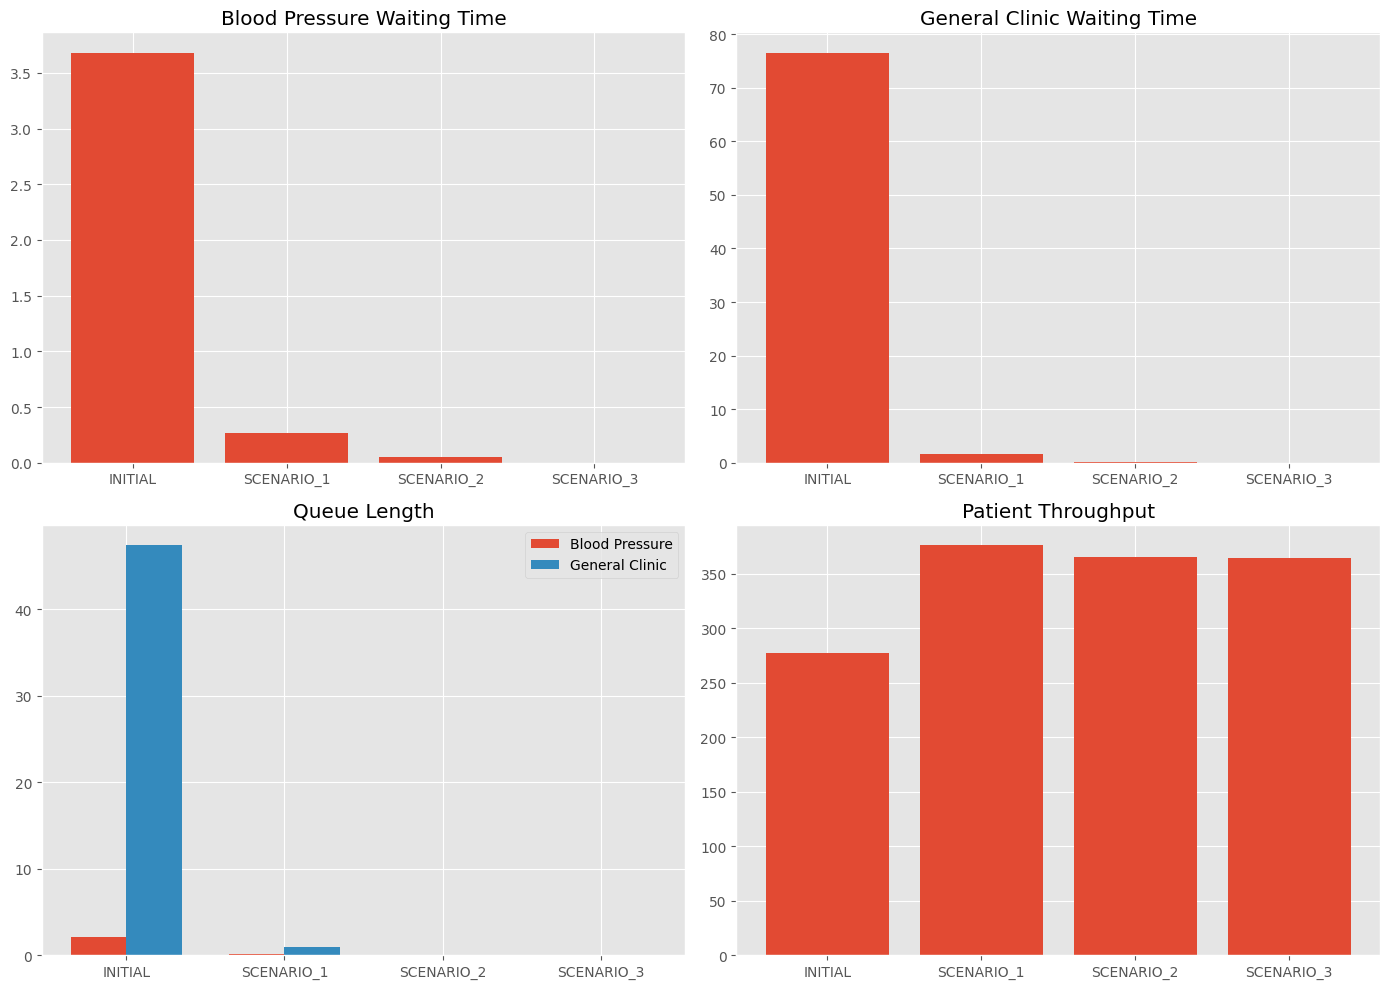

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize = (14, 10))
scenarios = results_df["scenario"]

# Waiting BP
axes[0,0].bar(scenarios, results_df["bp_waiting_time"])
axes[0,0].set_title("Blood Pressure Waiting Time")

# Waiting GC
axes[0,1].bar( scenarios, results_df["general_waiting_time"])
axes[0,1].set_title("General Clinic Waiting Time")

# Queue Length
x = range(len(scenarios))
width = 0.35

axes[1,0].bar([i-width/2 for i in x], results_df["bp_queue_length"], width, label = "Blood Pressure")
axes[1,0].bar([i+width/2 for i in x], results_df["general_queue_length"], width, label = "General Clinic")

axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(scenarios)
axes[1,0].legend()
axes[1,0].set_title("Queue Length")

# Throughput
axes[1,1].bar(scenarios, results_df["patients_completed"])
axes[1,1].set_title("Patient Throughput")

plt.tight_layout()
plt.show()

In [ ]:
best = results_df.loc[results_df["general_waiting_time"].idxmin()]

print(
    f"Skenario terbaik berdasarkan waiting time adalah "
    f"{best['scenario']}"
)

Skenario terbaik berdasarkan waiting time adalah SCENARIO_3
